# RobotEmotions IMU Plot (directly from CSVs)

This notebook lets you choose the capture by `domain`, `user`, and `tag`, and plot only a subset of sensors.

Sensor order in the CSV:
1. `waist`
2. `head_left`
3. `right_forearm`
4. `left_forearm`

In [5]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "evaluation").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Project root not found. Open the notebook inside the IMUGPT repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.utils import (
    list_capture_options,
    plot_robotemotions_imus_csv,
    prepare_robotemotions_capture,
    resolve_csv_path,
)

# Adjust the dataset root path here if needed
DATASET_ROOT = PROJECT_ROOT / "data" / "RobotEmotions"

# Capture selection variables
DOMAIN = "30ms"
USER = 2
TAG = 5

# Choose a subset of sensors (valid names below)
SENSOR_ORDER = ["waist", "head_left", "right_forearm", "left_forearm"]
SELECTED_SENSORS = ["right_forearm"]

# Channels to plot per sensor
MODALITIES = ["acc", "gyro"]

# Optional sample window; use None to plot everything
START_IDX = 0
END_IDX = None

In [6]:
options = list_capture_options(DATASET_ROOT)
print("Available domains:", list(options.keys()))
if DOMAIN in options:
    print(f"Users in {DOMAIN}:", list(options[DOMAIN].keys()))
    if USER in options[DOMAIN]:
        print(f"Tags for User{USER}:", options[DOMAIN][USER])

csv_path = resolve_csv_path(DATASET_ROOT, DOMAIN, USER, TAG)
print("Selected CSV:", csv_path)

Available domains: ['10ms', '30ms']
Users in 30ms: [1, 2, 3, 4, 5, 6, 8]
Tags for User2: [1, 2, 3, 5, 6, 7, 8, 9]
Selected CSV: /home/henriquesouza/IMUGPT/data/RobotEmotions/30ms/User2/Tag5/ESP_2_5.csv


In [7]:
prepared = prepare_robotemotions_capture(
    csv_path,
    sensor_order=SENSOR_ORDER,
    selected_sensors=SELECTED_SENSORS,
    start_idx=START_IDX,
    end_idx=END_IDX,
)

df = prepared["df"]
timestamps_sec = prepared["timestamps_sec"]
sample_slice = prepared["sample_slice"]
sensor_to_index = prepared["sensor_to_index"]

print("Total columns:", len(df.columns))
print("First columns:", list(df.columns[:12]))

Total columns: 38
First columns: ['timestamp', 'acc_X_1', 'acc_Y_1', 'acc_Z_1', 'gyro_X_1', 'gyro_Y_1', 'gyro_Z_1', 'pitch_1', 'roll_1', 'yaw_1', 'acc_X_2', 'acc_Y_2']


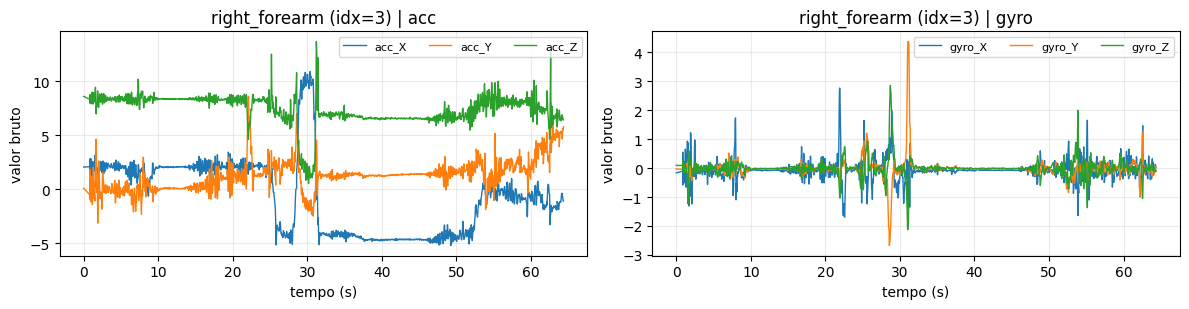

In [8]:
csv_path, df, fig = plot_robotemotions_imus_csv(
    dataset_root=DATASET_ROOT,
    domain=DOMAIN,
    user=USER,
    tag=TAG,
    sensor_order=SENSOR_ORDER,
    selected_sensors=SELECTED_SENSORS,
    modalities=MODALITIES,
    start_idx=START_IDX,
    end_idx=END_IDX,
    show=True,
)